In [16]:
import xarray as xr
import numpy as np
import sys
sys.path.append("/home/jupyter-vincent2/vincent/process_profiles/noteboooks_2026/functions")
from create_rec_datasets import r_analysis_df
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import pandas as pd
plt.rcParams.update({'font.size': 20})

In [10]:
ds_CMA,df_CMA,df_XIEST_CMA,df_PHI_CMA,df_GRID_CMA,df_MU_CMA,df_lambda_CMA = r_analysis_df("CMA_masked")
ds_G,df_G,df_XIEST_G,df_PHI_G,df_GRID_G,df_MU_G,df_lambda_G = r_analysis_df("GLORYS_masked")
ds_CL,df_CL,df_XIEST_CL,df_PHI_CL,df_GRID_CL,df_MU_CL,df_lambda_CL = r_analysis_df("GLORYS_CL_masked")
ds_G_dense,df_G_dense,df_XIEST_G_dense,df_PHI_G_dense,df_GRID_G_dense,df_MU_G_dense,df_lambda_G_dense = r_analysis_df("GLORYS_masked",dense=True)

legend_fs = 15
G_color = "#0D160B"
CMA_color = "#008DD5"
CL_color = "#CB152B"

ds_G_og = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_anom.nc").load()
ds_G_og = ds_G_og.rename({"latitude":"lat","longitude":"long"})

ds_G.update({"time":ds_G_og.time.values})
ds_G_dense.update({"time":ds_G_og.time.values})
ds_CL.update({"time":ds_G_og.time.values})
ds_CMA.update({"time":ds_G_og.time.values})

204
204
204
204


<xarray.Dataset> Size: 252MB
Dimensions:     (time: 204, long: 39, lat: 39)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2007-01-15T12:26:24 ... 2023-12-15T...
  * long        (long) float64 312B 60.25 60.77 61.28 ... 78.72 79.23 79.74
  * lat         (lat) float64 312B -59.75 -59.23 -58.72 ... -41.28 -40.77 -40.26
Data variables: (12/301)
    phi1        (time) float64 2kB 0.07439 0.07775 0.08014 ... 0.1937 0.1984
    phi2        (time) float64 2kB 0.1985 0.2234 0.2637 ... -0.5414 -0.5158
    phi3        (time) float64 2kB 0.3825 0.3663 0.3539 ... 0.3299 0.3418 0.3476
    phi4        (time) float64 2kB 0.2917 0.3208 0.3439 ... 0.2584 0.273 0.2847
    phi5        (time) float64 2kB 0.1001 0.1502 0.2026 ... -0.6813 -0.7281
    phi6        (time) float64 2kB 0.03184 0.07279 0.07571 ... -0.01196 -0.07668
    ...          ...
    xi_phi96    (long, lat, time) float64 2MB -1.465e-09 4.49e-09 ... 2.418e-09
    xi_phi97    (long, lat, time) float64 2MB 3.725e-12 -4.693e-10 ... 7.82e-10
    xi_phi98    (long, lat, time) float64 2MB -1.129e-10 2.81e-10 ... -3.637e-09
    xi_phi99    (long, lat, time) float64 2MB 1.696e-10 ... -5.298e-10
    xi_phi_tot  (long, lat, time) float64 2MB -4.766 -5.097 ... 6.13 7.636
    mld         (time, long, lat) float64 2MB -7.013 -2.737 ... -3.053 6.904

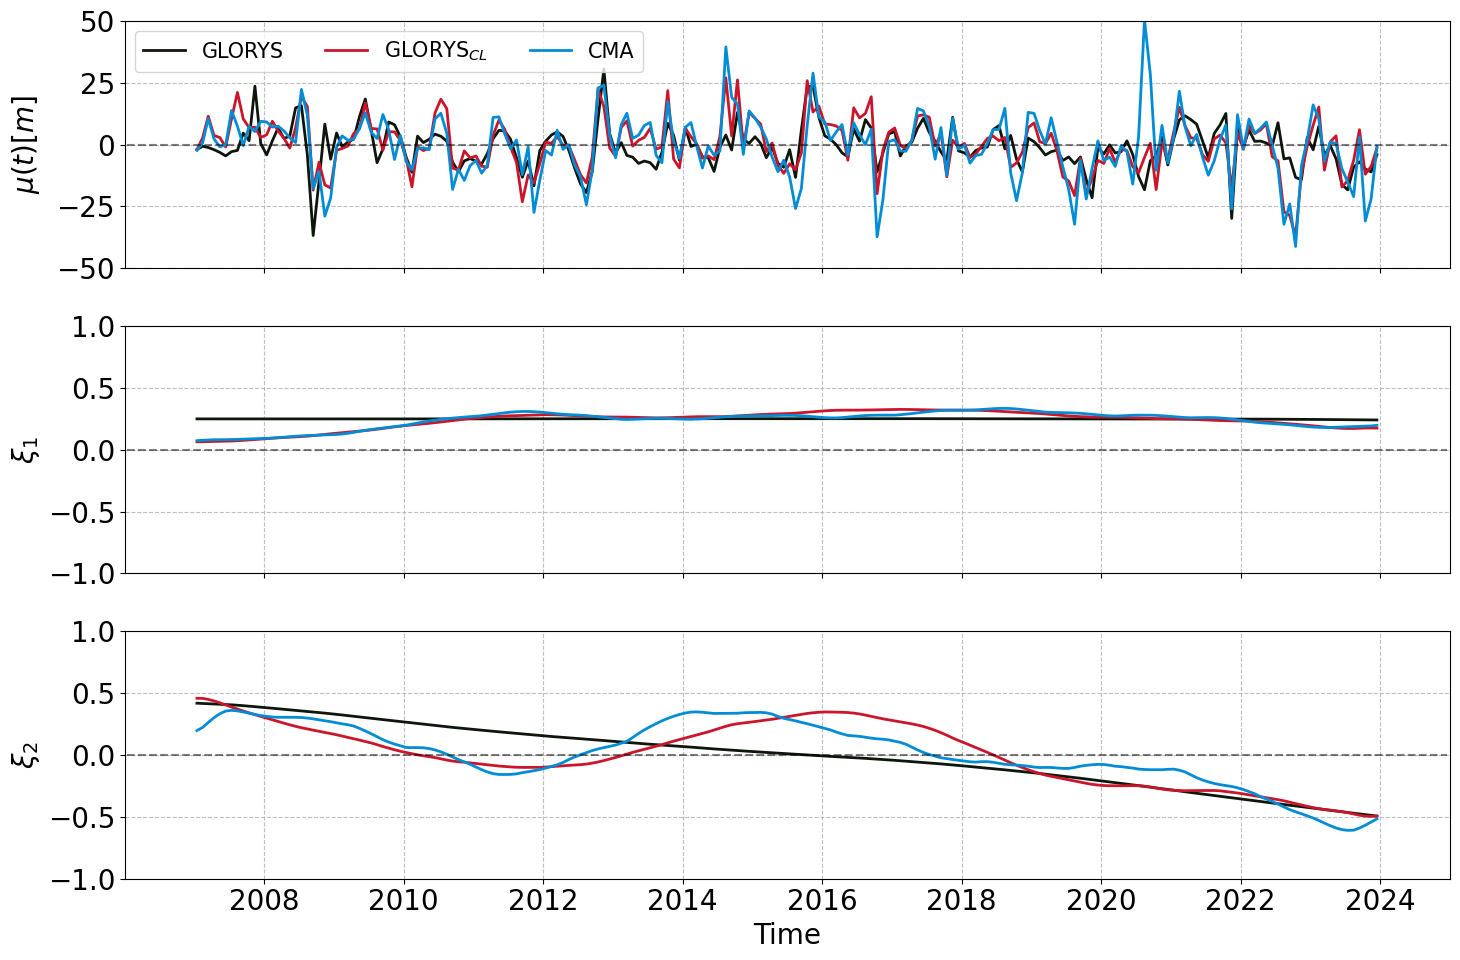

In [52]:
fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True, tight_layout=True)

# (1) MU
ax[0].plot(ds_G_dense.time, ds_G_dense.MU, color=G_color, linewidth=2, label="GLORYS")
ax[0].plot(ds_CL.time, ds_CL.MU, color=CL_color, linewidth=2, label="GLORYS$_{CL}$")
ax[0].plot(ds_CMA.time, ds_CMA.MU, color=CMA_color, linewidth=2, label="CMA")
ax[0].hlines(0, ds_CMA.time.min()-pd.Timedelta(days=365), ds_CMA.time.max()+pd.Timedelta(days=365), color="k", linestyle="--", alpha=0.5)
ax[0].set_xlim(pd.to_datetime("2006-01-02"), pd.to_datetime("2025-01-01"))
ax[0].set_ylim(-50,50)
ax[0].set_ylabel("MU [m]")
ax[0].set_ylabel("$\\mu (t) [m]$")
ax[0].legend(fontsize=legend_fs, loc="upper left", ncol=3)

# (2-4) First 2 modes
for i in range(1, 3):
    mode = f"phi{i}"
    ax[i].plot(ds_G_dense.time, ds_G_dense[mode], color=G_color, linewidth=2, label="GLORYS")
    ax[i].plot(ds_CL.time, ds_CL[mode], color=CL_color, linewidth=2, label="GLORYS$_{CL}$")
    ax[i].plot(ds_CMA.time, ds_CMA[mode], color=CMA_color, linewidth=2, label="CMA")
    ax[i].set_ylabel(f"$\\xi_{i}$")
    ax[i].set_ylim(-1,1)
    ax[i].hlines(0, ds_CMA.time.min()-pd.Timedelta(days=365), ds_CMA.time.max()+pd.Timedelta(days=365), color="k", linestyle="--", alpha=0.5)
    ax[i].set_xlim(pd.to_datetime("2006-01-02"), pd.to_datetime("2025-01-01"))

    if i == 2:
        ax[i].set_xlabel("Time")

for a in ax:
    a.grid(True, linestyle="--", alpha=0.8)

fig.align_ylabels()
plt.show()

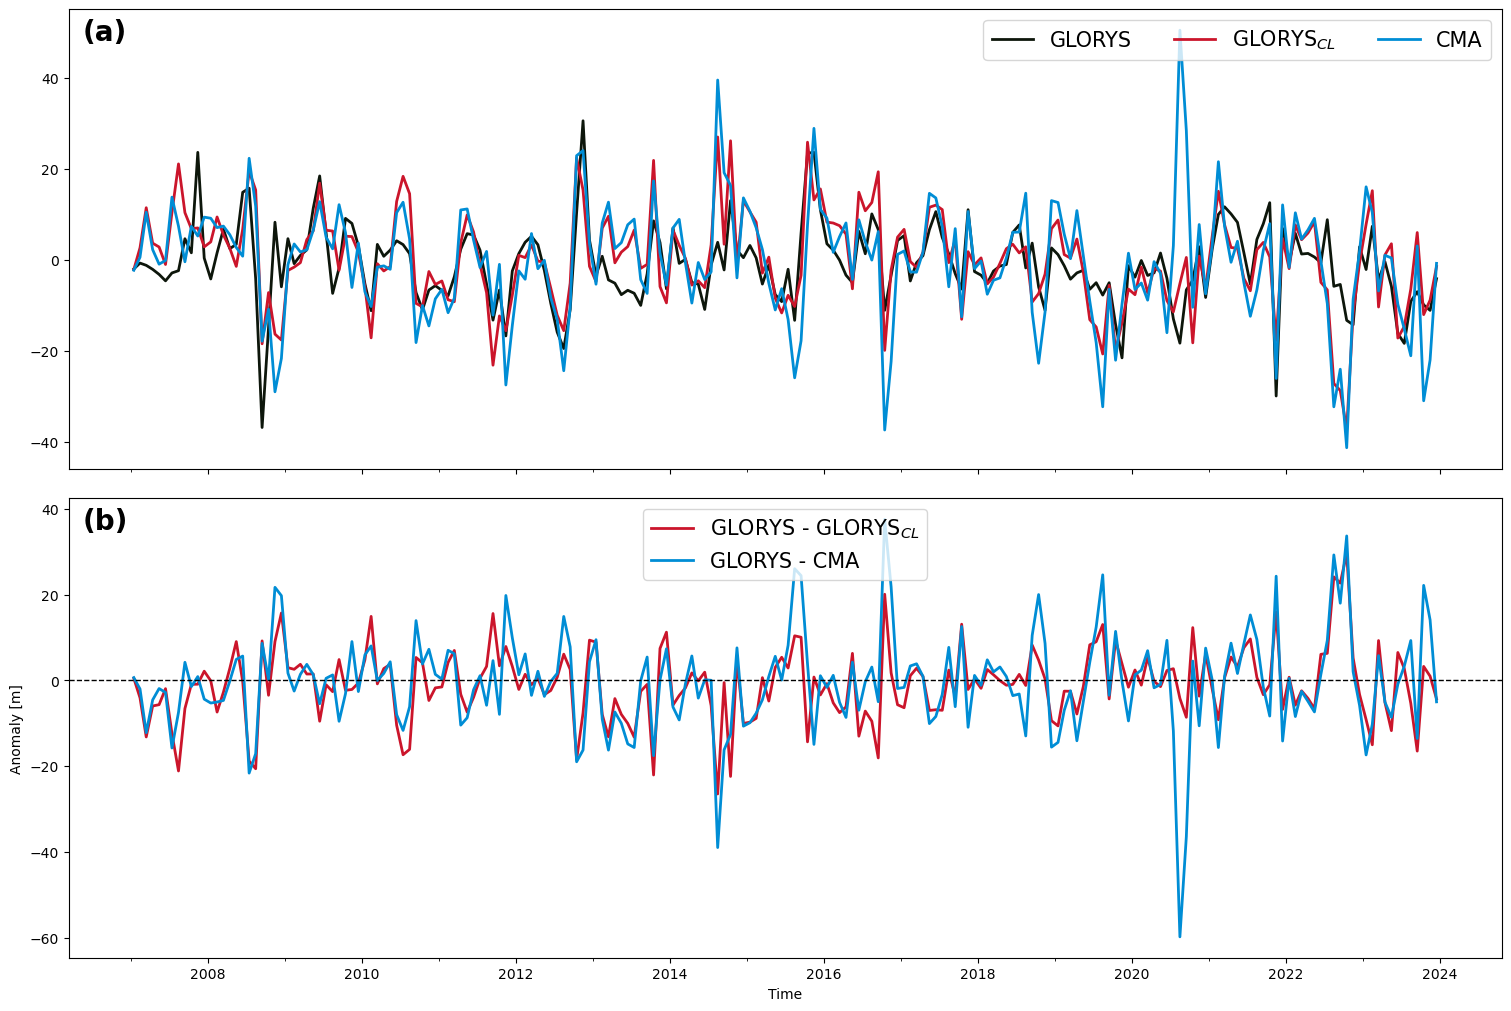

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10), sharex=True, constrained_layout=True, gridspec_kw={'hspace': 0.05})

ax[0].plot(ds_G_dense.time, ds_G_dense.MU, label="GLORYS", color=G_color, linewidth=2)
ax[0].plot(ds_CL.time, ds_CL.MU, label="GLORYS$_{CL}$", color=CL_color, linewidth=2)
ax[0].plot(ds_CMA.time, ds_CMA.MU, label="CMA", color=CMA_color, linewidth=2)
# ax[0].set_title(" (a) Reconstructed mean $\mu (t)$",loc="left")
ax[0].legend(loc="upper right", ncol=3, fontsize=legend_fs)
# ax[0].set_ylim(30,200)

ax[1].plot(ds_CL.time, ds_G.MU - ds_CL.MU, label="GLORYS - GLORYS$_{CL}$", color=CL_color, linewidth=2)
ax[1].plot(ds_CMA.time, ds_G.MU - ds_CMA.MU, label="GLORYS - CMA", color=CMA_color, linewidth=2)
ax[1].axhline(0, color="k", linestyle="--", linewidth=1)
ax[1].set_ylabel("Anomaly [m]")
# ax[1].set_title("(b) Anomalies relative to GLORYS",loc="left")
# ax[1].set_ylim(-40,40)
ax[1].legend(fontsize=legend_fs,loc="upper center")

ax[1].xaxis.set_major_locator(mdates.YearLocator(2))
ax[1].xaxis.set_minor_locator(mdates.YearLocator(1))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax[1].set_xlabel("Time")

for i, ax_i in enumerate(ax):
    ax_i.text(
        0.01, 0.98, f"({chr(97+i)})",
        transform=ax_i.transAxes,
        ha="left", va="top",
        fontsize=20, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
    )

plt.show()
# fig.savefig("/home/jupyter-vincent2/vincent/process_profiles/figures_2026/Figure_3_MU_comparison.png", bbox_inches="tight", dpi=300)